# Joseph's Analysis — Industrial-Logistics Coupling, Otay Mesa
## GPEC 447 | San Diego Border Zone Project

**Run order (all in this notebook):**
1. **Part A — Setup** — imports, CRS, constants, study area definitions
2. **Part B — Business Points** — load Christian's geocoded CSV, assign subareas
3. **Part C — LODES Enrichment** — pull Census LODES WAC tract-level industrial jobs
4. **Part D — Indicator 1** — distance to nearest port of entry
5. **Part E — Indicator 1b** — distance to nearest freight road
6. **Part F — Indicator 2** — freight corridor buffer overlap
7. **Part G — Export** — save joseph_indicators_output.csv + .geojson + lodes CSV
8. **Part H — Visualizations** — maps and charts
9. **Part I — Statistical Analysis** — pairwise Mann-Whitney U + Chi-square

**Prerequisites:**
- `industrial_businesses_core_geocoded.csv` (from Christian's pipeline)
- `Community_Plan_SD.geojson` (City of San Diego planning districts)

**Outputs:**
- `joseph_indicators_output.csv` / `.geojson`
- `lodes_enrichment_by_tract.csv` (for Canyu's Hook A)
- `map1_overview.png`, `map2_poe_distance_with_areas.png`
- `map3_otay_buffers.png`, `map4_kde_all_areas.png`
- `chart_buffer_comparison.png`, `chart_poe_boxplot.png`
- `chart_effect_sizes.png`, `stats_summary.csv`


---
## Part A — Setup

In [1]:
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import Point, box
from io import BytesIO
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── CRS — matches Christian's pipeline exactly ────────────────────────────────
CRS_GEO  = "EPSG:4326"    # geographic lat/lon
CRS_PROJ = "EPSG:3310"    # California Albers (meters)

METERS_PER_MILE = 1609.34

# ── Buffer distances in meters (0.25 / 0.50 / 1.00 mi) ───────────────────────
BUFFER_DISTANCES_M = {
    "buffer_quarter_mi": 402,
    "buffer_half_mi":    805,
    "buffer_one_mi":     1609,
}

# ── Input files ───────────────────────────────────────────────────────────────
INPUT_CSV           = "industrial_businesses_core_geocoded.csv"
COMMUNITY_PLAN_FILE = "Community_Plan_SD.geojson"

# ── Study area mapping: CPNAME -> study area label ────────────────────────────
# Otay Mesa     = OTAY MESA + OTAY MESA-NESTOR  (matches Christian str.contains)
# Kearny Mesa   = KEARNY MESA
# Miramar       = MIRAMAR RANCH NORTH + SCRIPPS MIRAMAR RANCH
# Sorrento Valley = MIRA MESA (no official Sorrento Valley planning district)
STUDY_AREA_MAP = {
    "OTAY MESA":             "Otay Mesa",
    "OTAY MESA-NESTOR":      "Otay Mesa",
    "KEARNY MESA":           "Kearny Mesa",
    "MIRAMAR RANCH NORTH":   "Miramar",
    "SCRIPPS MIRAMAR RANCH": "Miramar",
    "MIRA MESA":             "Sorrento Valley",
}
STUDY_AREAS      = ["Otay Mesa", "Kearny Mesa", "Miramar", "Sorrento Valley"]
BORDER_AREA      = "Otay Mesa"
COMPARISON_AREAS = ["Kearny Mesa", "Miramar", "Sorrento Valley"]

AREA_COLORS = {
    "Otay Mesa":       "#e8522a",
    "Kearny Mesa":     "#2c7bb6",
    "Miramar":         "#1a9641",
    "Sorrento Valley": "#7b3294",
    "Other":           "#d9d9d9",
}

# ── LODES configuration ───────────────────────────────────────────────────────
LODES_YEAR     = 2021      # latest available CA year; check lehd.ces.census.gov
LODES_STATE    = "ca"
LODES_JOB_TYPE = "JT00"   # all jobs
LODES_SEGMENT  = "S000"   # all workers
SD_COUNTY_FIPS = "073"

# LODES WAC NAICS sector columns
LODES_NAICS_COLS = {
    "CNS05": "lodes_mfg_jobs",    # Manufacturing (NAICS 31-33)
    "CNS06": "lodes_whole_jobs",   # Wholesale Trade (NAICS 42)
    "CNS08": "lodes_trans_jobs",   # Transportation & Warehousing (NAICS 48-49)
}

# ── Census TIGER tracts URL ───────────────────────────────────────────────────
TRACT_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/"
    "cb_2023_06_tract_500k.zip"
)

# ── SANDAG URLs ───────────────────────────────────────────────────────────────
SANDAG_POE_URL   = "https://gis.sandag.org/FreightViewer/data/poe_points_update.json"
SANDAG_ROADS_URL = "https://gis.sandag.org/FreightViewer/data/MajorRoads_20171002.json"

# ── Buffer cols/labels for charts ────────────────────────────────────────────
buf_cols   = list(BUFFER_DISTANCES_M.keys())
buf_labels = ["0.25 mi", "0.50 mi", "1.00 mi"]

print("Setup complete.")
print(f"  CRS:    {CRS_PROJ}")
print(f"  Buffers (m): {BUFFER_DISTANCES_M}")
print(f"  LODES year:  {LODES_YEAR}")


Setup complete.
  CRS:    EPSG:3310
  Buffers (m): {'buffer_quarter_mi': 402, 'buffer_half_mi': 805, 'buffer_one_mi': 1609}
  LODES year:  2021


---
## Part B — Load Business Points & Assign Subareas

In [2]:
# ── Load Christian's geocoded CSV ─────────────────────────────────────────────
df = pd.read_csv(INPUT_CSV, dtype=str)
print(f"Loaded {len(df)} rows | Columns: {df.columns.tolist()}")

df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df = df.dropna(subset=["longitude", "latitude"]).reset_index(drop=True)
print(f"Valid coordinates: {len(df)}")

businesses = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs=CRS_GEO
).to_crs(CRS_PROJ)

print(f"GeoDataFrame CRS: {businesses.crs}")

# ── Load Community Planning Districts ─────────────────────────────────────────
planning = gpd.read_file(COMMUNITY_PLAN_FILE)
if planning.crs is None:
    planning = planning.set_crs(CRS_GEO)
planning = planning.to_crs(CRS_PROJ)
print(f"Planning districts: {len(planning)} features")

# ── Clip to SD city planning boundary ────────────────────────────────────────
sd_boundary = planning.geometry.unary_union
sd_county   = gpd.GeoDataFrame(geometry=[sd_boundary], crs=CRS_PROJ)
before = len(businesses)
businesses = businesses[businesses.geometry.within(sd_boundary)].copy().reset_index(drop=True)
print(f"Clipped: {before} -> {len(businesses)} businesses within SD planning areas")

# ── Spatial join: assign planning area ───────────────────────────────────────
businesses = gpd.sjoin(
    businesses,
    planning[["CPNAME", "geometry"]],
    how="left", predicate="within"
).drop(columns=["index_right"], errors="ignore")

businesses["CPNAME"]  = businesses["CPNAME"].fillna("Outside City Planning Areas")
businesses["subarea"] = businesses["CPNAME"].map(STUDY_AREA_MAP).fillna("Other")

print("\nSubarea counts:")
print(businesses["subarea"].value_counts())

# ── Build per-subarea GeoDataFrames ──────────────────────────────────────────
subarea_gdfs = {area: businesses[businesses["subarea"] == area] for area in STUDY_AREAS}
subarea_gdfs["Other"] = businesses[businesses["subarea"] == "Other"]
otay   = subarea_gdfs["Otay Mesa"]
nonbdr = businesses[businesses["subarea"] != "Otay Mesa"]
print(f"\nOtay Mesa: {len(otay)} | Non-border total: {len(nonbdr)}")


Loaded 3067 rows | Columns: ['business_acctnum', 'dba_name', 'ownership_type', 'address', 'city', 'state', 'zip', 'naics', 'activity_desc', 'industry_group', 'definition', 'full_address', 'matched_address', 'geocode_score', 'longitude', 'latitude']
Valid coordinates: 3067
GeoDataFrame CRS: EPSG:3310
Planning districts: 61 features
Clipped: 3067 -> 2500 businesses within SD planning areas

Subarea counts:
subarea
Other              1380
Otay Mesa           493
Sorrento Valley     369
Kearny Mesa         206
Miramar              52
Name: count, dtype: int64

Otay Mesa: 493 | Non-border total: 2007


---
## Part C — LODES Enrichment (Tract-Level Industrial Jobs)

Pulls Census LODES WAC data for California, aggregates from blocks to SD County tracts.
Outputs `lodes_enrichment_by_tract.csv` for Canyu's Hook A.

> **Why LODES instead of ESRI GeoEnrichment:** WAC data measures where workers are *employed* (not where they *reside* as in ACS). No ESRI license required. Recommended by Prof. Zaslavsky.

In [3]:
# ── Download LODES WAC file for California ────────────────────────────────────
LODES_URL = (
    f"https://lehd.ces.census.gov/data/lodes/LODES8/{LODES_STATE}/wac/"
    f"{LODES_STATE}_wac_{LODES_SEGMENT}_{LODES_JOB_TYPE}_{LODES_YEAR}.csv.gz"
)
print(f"Downloading LODES WAC:\n  {LODES_URL}")
print("(~30-60 seconds — CA WAC file is ~50MB compressed)")

wac = pd.read_csv(LODES_URL, compression="gzip", dtype={"w_geocode": str})
print(f"Loaded: {len(wac):,} CA census blocks")

# ── Build tract GEOID and filter to San Diego County ─────────────────────────
# w_geocode = 15-digit block FIPS: state(2)+county(3)+tract(6)+block(4)
wac["GEOID"]    = wac["w_geocode"].str[:11]
wac["COUNTYFP"] = wac["w_geocode"].str[2:5]
wac_sd = wac[wac["COUNTYFP"] == SD_COUNTY_FIPS].copy()
print(f"San Diego County blocks: {len(wac_sd):,} | Unique tracts: {wac_sd['GEOID'].nunique()}")

# ── Verify NAICS columns ──────────────────────────────────────────────────────
missing = [c for c in LODES_NAICS_COLS if c not in wac_sd.columns]
if missing:
    print(f"WARNING: missing columns {missing}")
    print("Available CNS cols:", [c for c in wac_sd.columns if c.startswith("CNS")])
else:
    print("All expected NAICS columns present.")

# ── Aggregate blocks -> tracts ────────────────────────────────────────────────
agg_cols = list(LODES_NAICS_COLS.keys()) + ["C000"]
tract_lodes = (
    wac_sd.groupby("GEOID")[agg_cols]
    .sum().reset_index()
    .rename(columns={**LODES_NAICS_COLS, "C000": "lodes_total_jobs"})
)

ind_cols = list(LODES_NAICS_COLS.values())
tract_lodes["lodes_industrial_jobs"]  = tract_lodes[ind_cols].sum(axis=1)
tract_lodes["lodes_industrial_share"] = (
    tract_lodes["lodes_industrial_jobs"] /
    tract_lodes["lodes_total_jobs"].replace(0, np.nan)
)

print(f"\nTract-level LODES: {len(tract_lodes):,} tracts")
print(tract_lodes[["lodes_mfg_jobs","lodes_whole_jobs","lodes_trans_jobs",
                    "lodes_industrial_jobs","lodes_industrial_share"]].describe().round(2))

# ── Merge onto TIGER tract geometries ────────────────────────────────────────
print("\nLoading Census TIGER 2023 tracts...")
tracts_ca = gpd.read_file(TRACT_URL)
tracts_sd = tracts_ca[tracts_ca["COUNTYFP"] == SD_COUNTY_FIPS].copy()
tracts_sd["GEOID"] = tracts_sd["GEOID"].astype(str)
tracts_merged = tracts_sd[["GEOID"]].merge(tract_lodes, on="GEOID", how="left")
tracts_merged[ind_cols + ["lodes_industrial_jobs","lodes_industrial_share","lodes_total_jobs"]] = (
    tracts_merged[ind_cols + ["lodes_industrial_jobs","lodes_industrial_share","lodes_total_jobs"]]
    .fillna(0)
)

# ── Export for Canyu's Hook A ────────────────────────────────────────────────
lodes_out_cols = ["GEOID","lodes_mfg_jobs","lodes_whole_jobs","lodes_trans_jobs",
                  "lodes_industrial_jobs","lodes_industrial_share","lodes_total_jobs"]
tracts_merged[lodes_out_cols].to_csv("lodes_enrichment_by_tract.csv", index=False)
print("\nSaved: lodes_enrichment_by_tract.csv")
print(f"  {len(tracts_merged):,} rows | {len(lodes_out_cols)} columns")
print("\nTop 5 tracts by industrial jobs:")
print(
    tracts_merged.nlargest(5, "lodes_industrial_jobs")
    [["GEOID","lodes_industrial_jobs","lodes_industrial_share"]]
    .to_string(index=False)
)


  https://lehd.ces.census.gov/data/lodes/LODES8/ca/wac/ca_wac_S000_JT00_2021.csv.gz
(~30-60 seconds — CA WAC file is ~50MB compressed)
Loaded: 252,472 CA census blocks
San Diego County blocks: 15,976 | Unique tracts: 735
All expected NAICS columns present.

Tract-level LODES: 735 tracts
       lodes_mfg_jobs  lodes_whole_jobs  lodes_trans_jobs  \
count          735.00            735.00            735.00   
mean           155.76             60.79             42.84   
std            829.16            282.56            249.19   
min              0.00              0.00              0.00   
25%              0.00              0.00              0.00   
50%              3.00              6.00              3.00   
75%             19.50             22.00             13.00   
max           8889.00           3798.00           4504.00   

       lodes_industrial_jobs  lodes_industrial_share  
count                 735.00                  735.00  
mean                  259.39                    0.07

---
## Part D — Indicator 1: Distance to Nearest Port of Entry

In [4]:
# ── Fetch SANDAG POE points ───────────────────────────────────────────────────
print("Fetching SANDAG POE points...")
try:
    poe_pts = gpd.read_file(
        BytesIO(requests.get(SANDAG_POE_URL, timeout=60).content)
    ).to_crs(CRS_PROJ)
    print(f"POE points: {len(poe_pts)} features")
except Exception as e:
    print(f"[fallback] {e}")
    poe_pts = gpd.GeoDataFrame(
        {"port_name": ["San Ysidro POE", "Otay Mesa POE"]},
        geometry=[Point(-117.0295, 32.5440), Point(-116.9447, 32.5726)],
        crs=CRS_GEO
    ).to_crs(CRS_PROJ)
    print("Using hardcoded POE fallback.")

poe_name_col = next(
    (c for c in poe_pts.columns if "name" in c.lower() or "port" in c.lower()), None
)

if poe_name_col:
    poe_pts[poe_name_col] = poe_pts[poe_name_col].astype(str)
    sy_geom = poe_pts[poe_pts[poe_name_col].str.contains(
        "Ysidro|ysidro", na=False, case=False)].geometry.unary_union
    om_geom = poe_pts[poe_pts[poe_name_col].str.contains(
        "Otay|otay", na=False, case=False)].geometry.unary_union
else:
    sy_geom, om_geom = None, None

if sy_geom is None:
    sy_geom = gpd.GeoDataFrame(
        geometry=[Point(-117.0295, 32.5440)], crs=CRS_GEO
    ).to_crs(CRS_PROJ).geometry.iloc[0]

if om_geom is None:
    om_geom = gpd.GeoDataFrame(
        geometry=[Point(-116.9447, 32.5726)], crs=CRS_GEO
    ).to_crs(CRS_PROJ).geometry.iloc[0]

poe_union = poe_pts.geometry.unary_union

# ── Compute distances ─────────────────────────────────────────────────────────
businesses["dist_nearest_poe_m"]  = businesses.geometry.distance(poe_union)
businesses["dist_nearest_poe_mi"] = businesses["dist_nearest_poe_m"] / METERS_PER_MILE
businesses["dist_san_ysidro_m"]   = businesses.geometry.distance(sy_geom)
businesses["dist_san_ysidro_mi"]  = businesses["dist_san_ysidro_m"] / METERS_PER_MILE
businesses["dist_otay_poe_m"]     = businesses.geometry.distance(om_geom)
businesses["dist_otay_poe_mi"]    = businesses["dist_otay_poe_m"] / METERS_PER_MILE
businesses["nearest_poe_name"]    = np.where(
    businesses["dist_san_ysidro_m"] <= businesses["dist_otay_poe_m"],
    "San Ysidro", "Otay Mesa"
)

# ── POE hardcoded fallback for maps ──────────────────────────────────────────
poe_raw = gpd.GeoDataFrame(
    {"name": ["San Ysidro POE", "Otay Mesa POE"]},
    geometry=[Point(-117.0295, 32.5440), Point(-116.9447, 32.5726)],
    crs=CRS_GEO
).to_crs(CRS_PROJ)

print("\n── Distance to Nearest POE (miles) by Subarea ──")
print(
    businesses.groupby("subarea")["dist_nearest_poe_mi"]
    .agg(n="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(3)
)


Fetching SANDAG POE points...
POE points: 10 features

── Distance to Nearest POE (miles) by Subarea ──
                    n    mean  median    std     min     max
subarea                                                     
Kearny Mesa       206  20.545  20.745  0.667  18.278  21.953
Miramar            52  26.048  25.994  0.711  24.905  27.520
Otay Mesa         493   1.397   1.094  1.091   0.117   4.790
Other            1380  18.615  17.547  6.915   0.124  37.381
Sorrento Valley   369  25.364  24.992  0.798  24.174  27.755


---
## Part E — Indicator 1b: Distance to Nearest Freight Road

In [5]:
# ── Fetch SANDAG major roads ──────────────────────────────────────────────────
print("Fetching SANDAG Major Roads...")
major_roads = gpd.read_file(
    BytesIO(requests.get(SANDAG_ROADS_URL, timeout=60).content)
).to_crs(CRS_PROJ)
print(f"Major roads: {len(major_roads)} features | CRS: {major_roads.crs}")

roads_dissolved = major_roads.dissolve().geometry.iloc[0]

# ── sjoin_nearest — matches Christian's method exactly ───────────────────────
nearest_road = gpd.sjoin_nearest(
    businesses,
    major_roads[["geometry"]],
    how="left",
    distance_col="dist_to_freight_road_m"
).drop(columns=["index_right"], errors="ignore")

businesses["dist_to_freight_road_m"]  = nearest_road["dist_to_freight_road_m"]
businesses["dist_to_freight_road_mi"] = businesses["dist_to_freight_road_m"] / METERS_PER_MILE

businesses["distance_category"] = pd.cut(
    businesses["dist_to_freight_road_mi"],
    bins=[0, 0.25, 0.5, 1, 2, businesses["dist_to_freight_road_mi"].max()],
    labels=["0-0.25 mi","0.25-0.5 mi","0.5-1 mi","1-2 mi","2+ mi"],
    include_lowest=True
)

print("\n── Distance to Freight Road (miles) by Subarea ──")
print(
    businesses.groupby("subarea")["dist_to_freight_road_mi"]
    .agg(n="count", mean="mean", median="median", min="min", max="max")
    .round(3)
)


Fetching SANDAG Major Roads...
Major roads: 45 features | CRS: EPSG:3310

── Distance to Freight Road (miles) by Subarea ──
                    n   mean  median    min    max
subarea                                           
Kearny Mesa       206  0.308   0.270  0.021  0.936
Miramar            52  0.997   0.541  0.118  3.154
Otay Mesa         493  0.321   0.275  0.006  1.189
Other            1380  0.696   0.450  0.020  3.587
Sorrento Valley   369  1.599   1.725  0.041  2.789


---
## Part F — Indicator 2: Freight Corridor Buffer Overlap

In [6]:
# Binary inside/outside flag for each buffer distance
for col, dist_m in BUFFER_DISTANCES_M.items():
    buf = roads_dissolved.buffer(dist_m)
    businesses[col] = businesses.geometry.within(buf)
    n_in  = int(businesses[col].sum())
    total = len(businesses)
    print(f"  {dist_m}m ({dist_m/METERS_PER_MILE:.2f} mi): "
          f"{n_in}/{total} inside ({100*n_in/total:.1f}%)")

print("\n── Buffer overlap by subarea ──")
for col, label in zip(buf_cols, buf_labels):
    print(f"\n{label}:")
    print(
        businesses.groupby("subarea")[col]
        .agg(n="count", n_inside="sum",
             pct_inside=lambda x: round(100*x.mean(), 1))
    )

# Update subarea_gdfs with new columns
subarea_gdfs = {area: businesses[businesses["subarea"] == area] for area in STUDY_AREAS}
subarea_gdfs["Other"] = businesses[businesses["subarea"] == "Other"]
otay   = subarea_gdfs["Otay Mesa"]
nonbdr = businesses[businesses["subarea"] != "Otay Mesa"]


  402m (0.25 mi): 733/2500 inside (29.3%)
  805m (0.50 mi): 1374/2500 inside (55.0%)
  1609m (1.00 mi): 1838/2500 inside (73.5%)

── Buffer overlap by subarea ──

0.25 mi:
                    n  n_inside  pct_inside
subarea                                    
Kearny Mesa       206        85        41.3
Miramar            52        13        25.0
Otay Mesa         493       200        40.6
Other            1380       423        30.7
Sorrento Valley   369        12         3.3

0.50 mi:
                    n  n_inside  pct_inside
subarea                                    
Kearny Mesa       206       186        90.3
Miramar            52        25        48.1
Otay Mesa         493       403        81.7
Other            1380       733        53.1
Sorrento Valley   369        27         7.3

1.00 mi:
                    n  n_inside  pct_inside
subarea                                    
Kearny Mesa       206       206       100.0
Miramar            52        34        65.4
Otay Mesa       

---
## Part G — Export Indicator Outputs

In [7]:
base_cols = [
    "business_acctnum","dba_name","industry_group","naics",
    "address","city","state","zip","latitude","longitude",
    "CPNAME","subarea",
    "dist_nearest_poe_m","dist_nearest_poe_mi",
    "dist_san_ysidro_m","dist_san_ysidro_mi",
    "dist_otay_poe_m","dist_otay_poe_mi",
    "nearest_poe_name",
    "dist_to_freight_road_m","dist_to_freight_road_mi",
    "distance_category",
]
keep = [c for c in base_cols + buf_cols if c in businesses.columns]
output_gdf = businesses[keep + ["geometry"]].copy()

output_gdf.drop(columns=["geometry"]).to_csv("joseph_indicators_output.csv", index=False)
output_gdf.to_crs(CRS_GEO).to_file("joseph_indicators_output.geojson", driver="GeoJSON")

print("Saved: joseph_indicators_output.csv")
print("Saved: joseph_indicators_output.geojson")
print(f"  {len(output_gdf):,} rows | {len(keep)} columns")

print("\n── FINAL VALIDATION SUMMARY ──")
print(
    businesses[["subarea","dist_nearest_poe_mi"] + buf_cols]
    .groupby("subarea").agg(["mean","count"]).round(3)
)


Saved: joseph_indicators_output.csv
Saved: joseph_indicators_output.geojson
  2,500 rows | 25 columns

── FINAL VALIDATION SUMMARY ──
                dist_nearest_poe_mi       buffer_quarter_mi        \
                               mean count              mean count   
subarea                                                             
Kearny Mesa                  20.545   206             0.413   206   
Miramar                      26.048    52             0.250    52   
Otay Mesa                     1.397   493             0.406   493   
Other                        18.615  1380             0.307  1380   
Sorrento Valley              25.364   369             0.033   369   

                buffer_half_mi       buffer_one_mi        
                          mean count          mean count  
subarea                                                   
Kearny Mesa              0.903   206         1.000   206  
Miramar                  0.481    52         0.654    52  
Otay Mesa         

---
## Part H — Visualizations

In [8]:
# ── Helper: planning district outlines ───────────────────────────────────────
planning["subarea"] = planning["CPNAME"].map(STUDY_AREA_MAP).fillna("Other")
study_area_polys = {}
for area in STUDY_AREAS:
    sub = planning[planning["subarea"] == area]
    if len(sub):
        study_area_polys[area] = sub.geometry.unary_union

LABEL_OFFSETS = {
    "Otay Mesa":       ( 25000, -12000),
    "Kearny Mesa":     (-35000,  12000),
    "Miramar":         ( 22000,  12000),
    "Sorrento Valley": (-48000,  12000),
}

def add_study_outlines(ax, zorder_base=3):
    for area, poly in study_area_polys.items():
        col = AREA_COLORS[area]
        cgdf = gpd.GeoDataFrame(geometry=[poly], crs=CRS_PROJ)
        cgdf.plot(ax=ax, color=col, alpha=0.10, zorder=zorder_base)
        cgdf.boundary.plot(ax=ax, color=col, linewidth=2.0,
                           linestyle="--", zorder=zorder_base+1)
        cx, cy = poly.centroid.x, poly.centroid.y
        dx, dy = LABEL_OFFSETS[area]
        is_border = "border" if area == BORDER_AREA else "comparison"
        ax.annotate(
            f"{area}\n({is_border})",
            xy=(cx, cy), xytext=(cx+dx, cy+dy),
            fontsize=9, fontweight="bold", color=col,
            ha="center", va="center",
            arrowprops=dict(arrowstyle="-", color=col, lw=1.2),
            bbox=dict(boxstyle="round,pad=0.28", fc="white",
                      ec=col, lw=1.3, alpha=0.94),
            zorder=zorder_base+2
        )

minx, miny, maxx, maxy = sd_county.total_bounds
margin = 5000

# ── Pre-compute buffer summary stats ─────────────────────────────────────────
def pct_inside(gdf_sub, col):
    return round(100 * gdf_sub[col].mean(), 1) if len(gdf_sub) else 0.0

buf_pcts = {
    area: [pct_inside(subarea_gdfs[area], c) for c in buf_cols]
    for area in STUDY_AREAS
}
print("Buffer overlap summary:")
for area in STUDY_AREAS:
    print(f"  {area}: {buf_pcts[area]}")


Buffer overlap summary:
  Otay Mesa: [40.6, 81.7, 98.6]
  Kearny Mesa: [41.3, 90.3, 100.0]
  Miramar: [25.0, 48.1, 65.4]
  Sorrento Valley: [3.3, 7.3, 17.6]


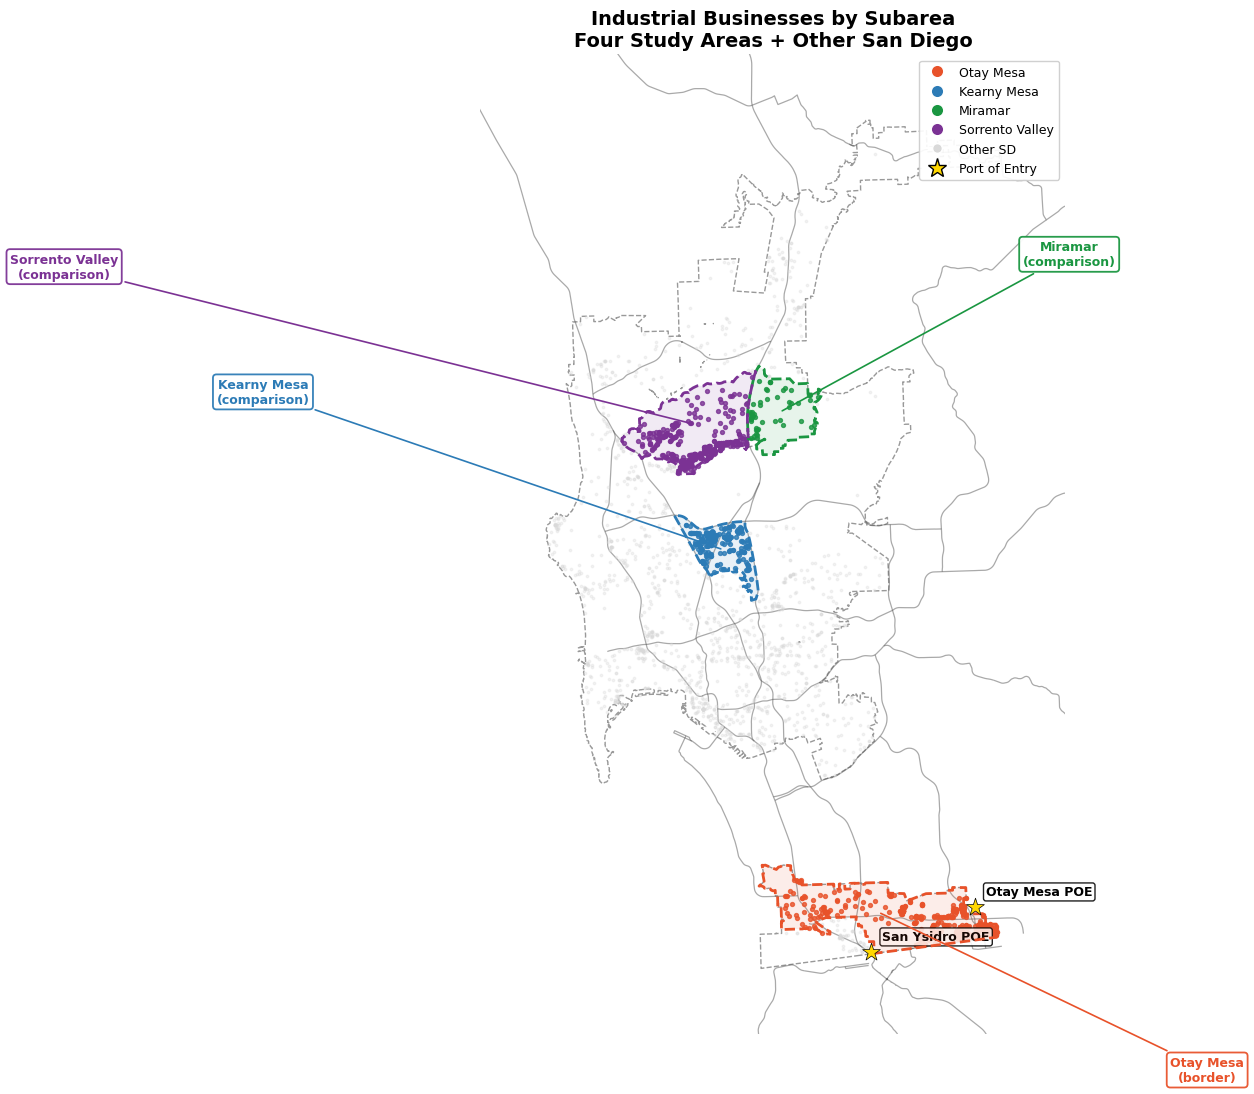

Saved: map1_overview.png


In [9]:
# ── Map 1 — Overview dot map ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
sd_county.plot(ax=ax, color="none", edgecolor="#999", linewidth=1.0,
               linestyle="--", zorder=0)
major_roads.plot(ax=ax, color="#555", linewidth=0.9, alpha=0.5, zorder=1)
subarea_gdfs["Other"].plot(ax=ax, color=AREA_COLORS["Other"],
                           markersize=3, alpha=0.3, zorder=2)
for area in STUDY_AREAS:
    subarea_gdfs[area].plot(ax=ax, color=AREA_COLORS[area],
                            markersize=8, alpha=0.8, zorder=3, label=area)
add_study_outlines(ax, zorder_base=4)
poe_raw.plot(ax=ax, color="gold", markersize=180, marker="*",
             zorder=7, edgecolor="black", linewidth=0.5)
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(8, 8), textcoords="offset points", fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.88))
ax.set_xlim(minx-margin, maxx+margin); ax.set_ylim(miny-margin, maxy+margin)
legend_els = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=AREA_COLORS[a],
           markersize=9, label=a) for a in STUDY_AREAS
] + [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=AREA_COLORS["Other"],
           markersize=7, label="Other SD"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",
           markersize=14, markeredgecolor="black", label="Port of Entry"),
]
ax.legend(handles=legend_els, loc="upper right", fontsize=9, framealpha=0.92)
ax.set_title("Industrial Businesses by Subarea\nFour Study Areas + Other San Diego",
             fontsize=14, fontweight="bold")
ax.set_axis_off(); plt.tight_layout()
plt.savefig("map1_overview.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: map1_overview.png")


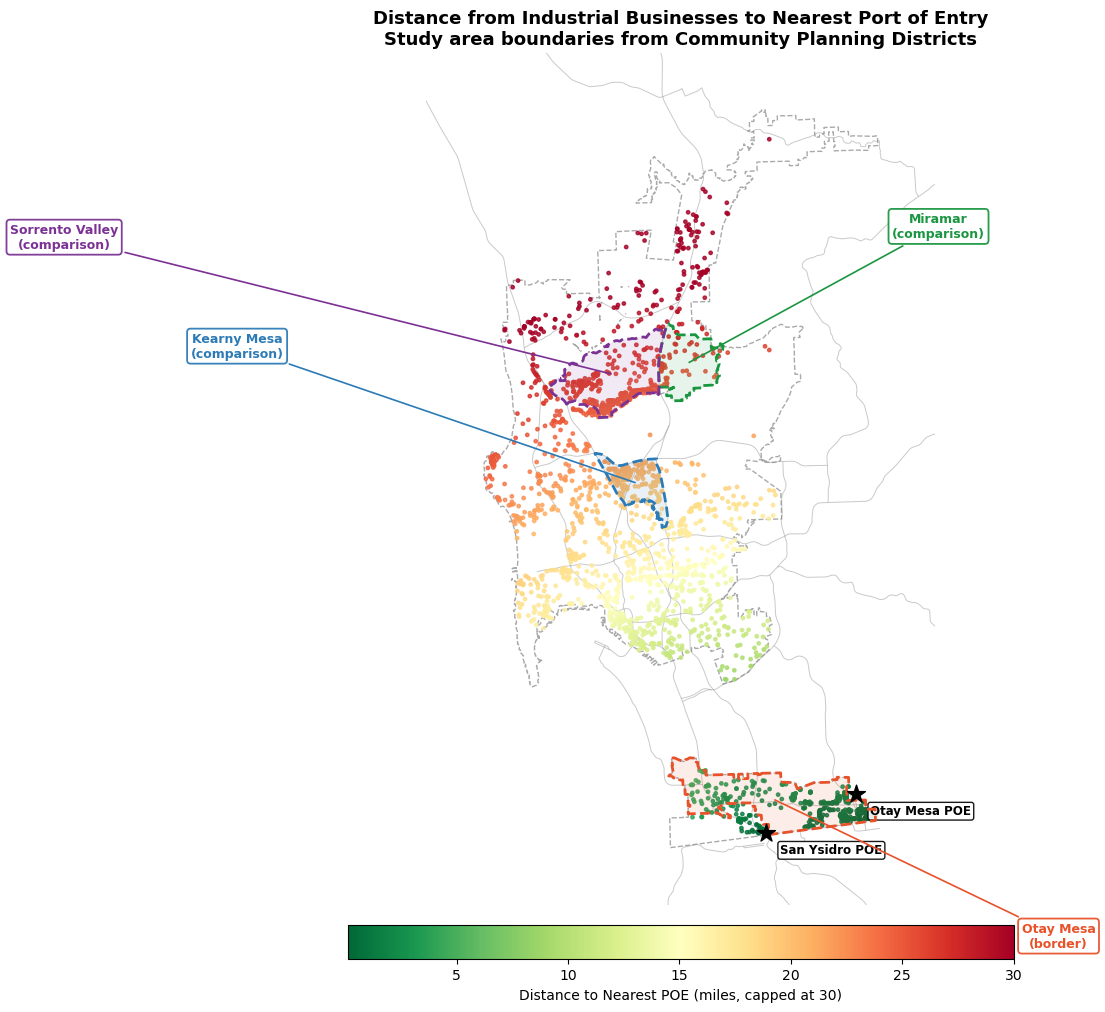

Saved: map2_poe_distance_with_areas.png


In [10]:
# ── Map 2 — POE distance graduated color ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
businesses["dist_capped"] = businesses["dist_nearest_poe_mi"].clip(upper=30)
sd_county.plot(ax=ax, color="none", edgecolor="#aaa", linewidth=1.0,
               linestyle="--", zorder=0)
major_roads.plot(ax=ax, color="#888", linewidth=0.7, alpha=0.45, zorder=1)
businesses.plot(ax=ax, column="dist_capped", cmap="RdYlGn_r", markersize=6,
                alpha=0.8, legend=True,
                legend_kwds={"label":"Distance to Nearest POE (miles, capped at 30)",
                             "orientation":"horizontal","shrink":0.55,"pad":0.02},
                zorder=2)
add_study_outlines(ax, zorder_base=3)
poe_raw.plot(ax=ax, color="black", markersize=180, marker="*", zorder=7)
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(10, -15), textcoords="offset points", fontsize=8.5,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9))
ax.set_xlim(minx-margin, maxx+margin); ax.set_ylim(miny-margin, maxy+margin)
ax.set_title("Distance from Industrial Businesses to Nearest Port of Entry\n"
             "Study area boundaries from Community Planning Districts",
             fontsize=13, fontweight="bold")
ax.set_axis_off(); plt.tight_layout()
plt.savefig("map2_poe_distance_with_areas.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: map2_poe_distance_with_areas.png")


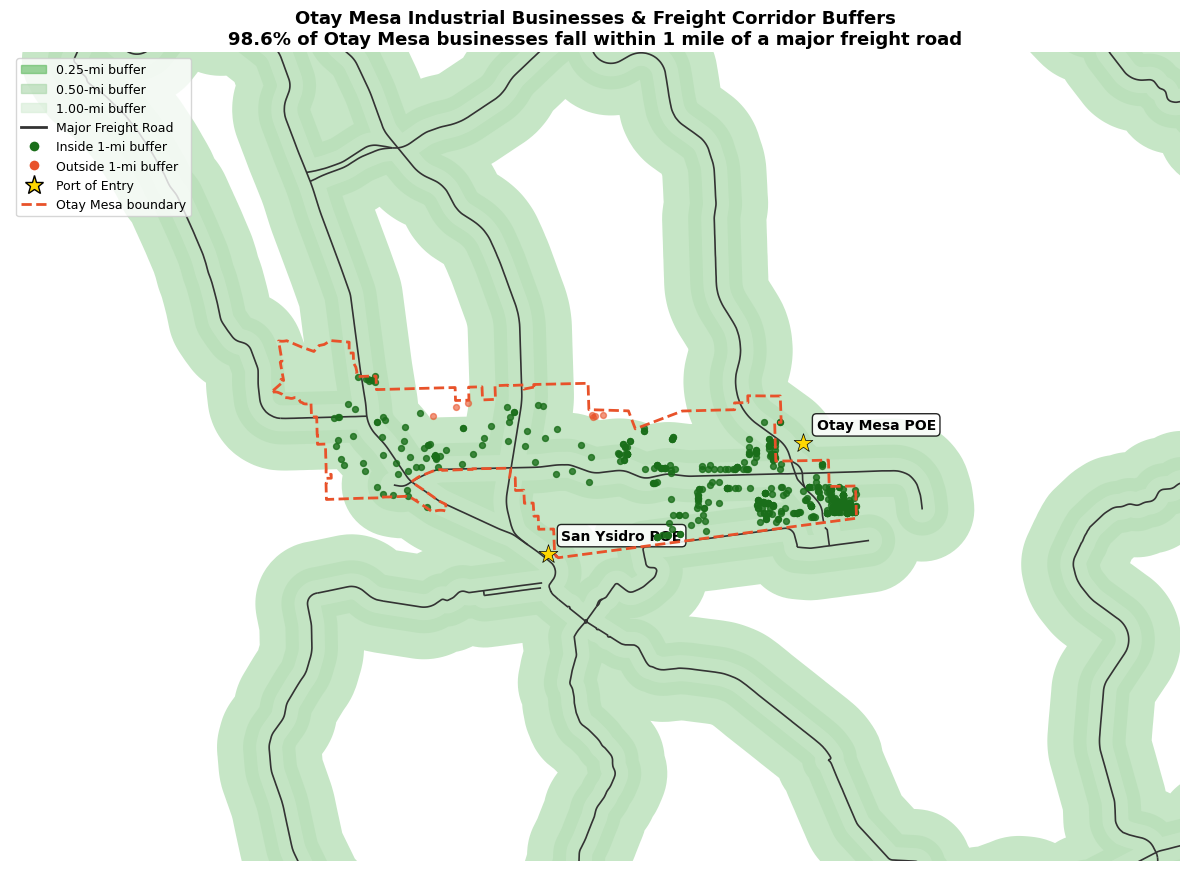

Saved: map3_otay_buffers.png


In [11]:
# ── Map 3 — Otay Mesa zoom: buffer rings ─────────────────────────────────────
buffers = {f"{v/METERS_PER_MILE:.2f} mi": roads_dissolved.buffer(v)
           for v in BUFFER_DISTANCES_M.values()}
otay_bounds = otay.total_bounds
margin_otay = 10000
xlim = (otay_bounds[0]-margin_otay, otay_bounds[2]+margin_otay)
ylim = (otay_bounds[1]-margin_otay, otay_bounds[3]+margin_otay)
pct_one_mi = round(100 * otay["buffer_one_mi"].mean(), 1)

fig, ax = plt.subplots(figsize=(12, 10))
buf_colors = ["#d4ecd4","#a8d5a8","#5cb85c"]
for (label, buf_geom), color in zip(reversed(list(buffers.items())), reversed(buf_colors)):
    gpd.GeoDataFrame(geometry=[buf_geom], crs=CRS_PROJ).plot(
        ax=ax, color=color, alpha=0.35, zorder=1)
major_roads.plot(ax=ax, color="#333", linewidth=1.2, zorder=2)
otay[otay["buffer_one_mi"]==False].plot(ax=ax, color="#e8522a", markersize=18,
                                         alpha=0.6, zorder=3, label="Outside 1-mi buffer")
otay[otay["buffer_one_mi"]==True].plot( ax=ax, color="#1a6e1a", markersize=18,
                                         alpha=0.8, zorder=4, label="Inside 1-mi buffer")
poe_raw.plot(ax=ax, color="gold", markersize=200, marker="*",
             zorder=6, edgecolor="black", linewidth=0.5)
for _, row in poe_raw.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(10, 10), textcoords="offset points", fontsize=10,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
if "Otay Mesa" in study_area_polys:
    gpd.GeoDataFrame(geometry=[study_area_polys["Otay Mesa"]], crs=CRS_PROJ).boundary.plot(
        ax=ax, color=AREA_COLORS["Otay Mesa"], linewidth=2.0, linestyle="--", zorder=5)
legend_elements = [
    mpatches.Patch(color="#5cb85c", alpha=0.6, label="0.25-mi buffer"),
    mpatches.Patch(color="#a8d5a8", alpha=0.6, label="0.50-mi buffer"),
    mpatches.Patch(color="#d4ecd4", alpha=0.6, label="1.00-mi buffer"),
    Line2D([0],[0], color="#333", linewidth=2, label="Major Freight Road"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#1a6e1a",
           markersize=8, label="Inside 1-mi buffer"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#e8522a",
           markersize=8, label="Outside 1-mi buffer"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",
           markersize=14, markeredgecolor="black", label="Port of Entry"),
    Line2D([0],[0], color=AREA_COLORS["Otay Mesa"], linewidth=2,
           linestyle="--", label="Otay Mesa boundary"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title(f"Otay Mesa Industrial Businesses & Freight Corridor Buffers\n"
             f"{pct_one_mi}% of Otay Mesa businesses fall within 1 mile of a major freight road",
             fontsize=13, fontweight="bold")
ax.set_axis_off(); plt.tight_layout()
plt.savefig("map3_otay_buffers.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: map3_otay_buffers.png")


In [21]:
import matplotlib.patches as mpatches

# Stat cards
for i, area in enumerate(STUDY_AREAS):
    ax = fig.add_axes([0.04 + i*0.245, 0.72, 0.225, 0.18])
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    col = AREA_COLORS_CHART[area]
    ax.add_patch(mpatches.Rectangle((0, 0.93), 1, 0.07,
                 transform=ax.transAxes, color=col,
                 clip_on=False, zorder=10))
    ax.text(0.5, 0.82, area, transform=ax.transAxes,
            ha="center", va="center", fontsize=11, fontweight="bold", color="#333")
    ax.text(0.5, 0.48, f"{medians[area]:.2f}",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=26, fontweight="bold", color=col)
    ax.text(0.5, 0.22, "miles (median)",
            transform=ax.transAxes, ha="center", va="center", fontsize=9, color="#888")
    ax.text(0.5, 0.05, "n = {:,}".format(counts[area]),
            transform=ax.transAxes, ha="center", va="center", fontsize=9, color="#aaa")

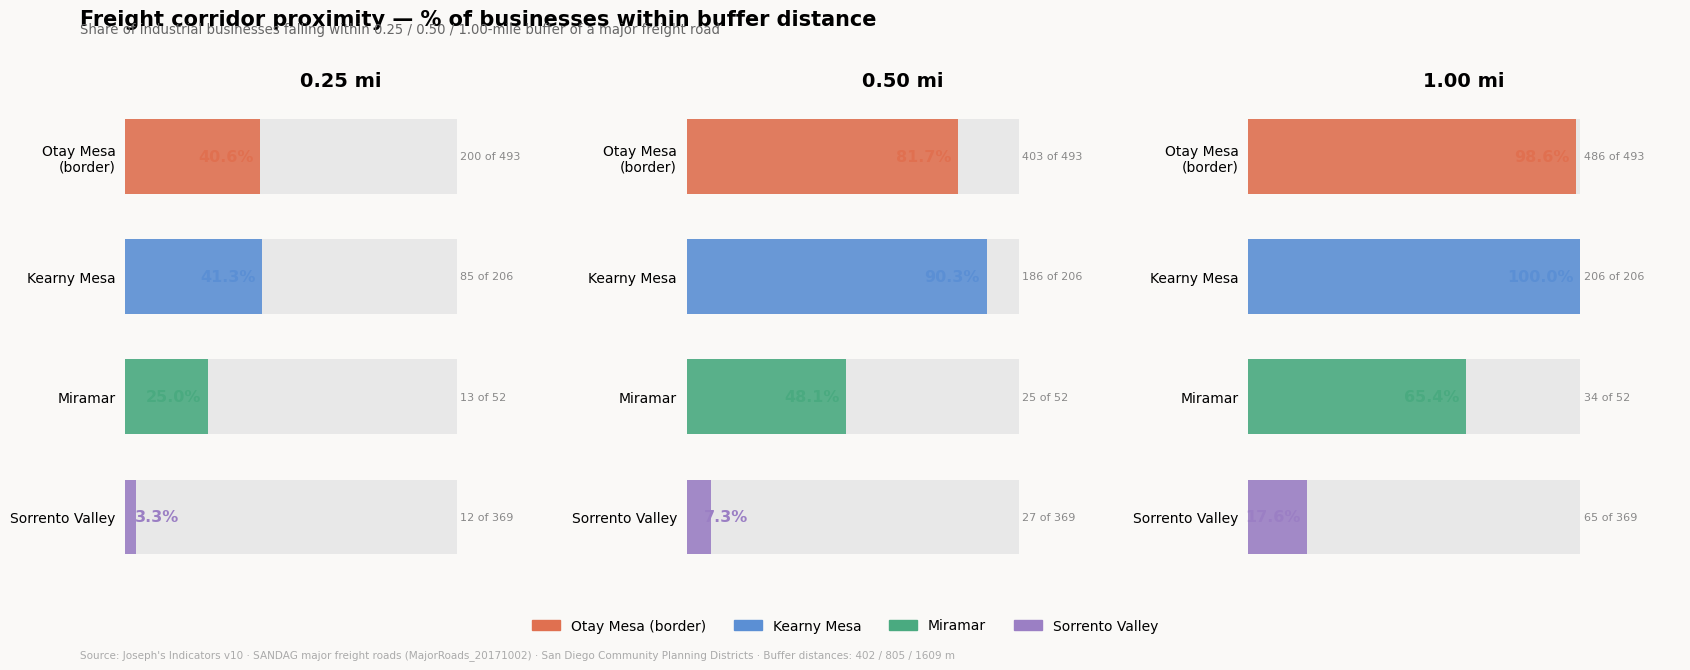

Saved: buffer_overlap_by_subarea.png


In [18]:
# ── Figure B — Freight corridor buffer overlap (horizontal diverging bars) ────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

AREA_COLORS_CHART = {
    "Otay Mesa":       "#e07050",
    "Kearny Mesa":     "#5b8fd4",
    "Miramar":         "#4aaa80",
    "Sorrento Valley": "#9b7fc4",
}
AREA_LABELS = {
    "Otay Mesa":       "Otay Mesa\n(border)",
    "Kearny Mesa":     "Kearny Mesa",
    "Miramar":         "Miramar",
    "Sorrento Valley": "Sorrento Valley",
}
buf_cols_chart  = ["buffer_quarter_mi", "buffer_half_mi", "buffer_one_mi"]
buf_titles      = ["0.25 mi", "0.50 mi", "1.00 mi"]

# Pre-compute stats
stats = {}
for area in STUDY_AREAS:
    sub = subarea_gdfs[area]
    n   = len(sub)
    stats[area] = {
        col: {"n_in": int(sub[col].sum()), "n": n,
              "pct": round(100 * sub[col].mean(), 1)}
        for col in buf_cols_chart
    }

fig, axes = plt.subplots(1, 3, figsize=(17, 6), facecolor="#faf9f7")
fig.suptitle("Freight corridor proximity — % of businesses within buffer distance",
             fontsize=15, fontweight="bold", x=0.05, ha="left", y=1.02)
fig.text(0.05, 0.98,
         "Share of industrial businesses falling within 0.25 / 0.50 / 1.00-mile "
         "buffer of a major freight road",
         fontsize=9.5, color="#666", ha="left")

y_pos = np.arange(len(STUDY_AREAS))

for ax, col, title in zip(axes, buf_cols_chart, buf_titles):
    ax.set_facecolor("#faf9f7")
    for i, area in enumerate(STUDY_AREAS):
        s   = stats[area][col]
        pct = s["pct"]
        col_color = AREA_COLORS_CHART[area]

        ax.barh(i, 100, height=0.62, color="#e8e8e8", zorder=1)
        ax.barh(i, pct, height=0.62, color=col_color, alpha=0.9, zorder=2)

        ax.text(101, i, "{:,} of {:,}".format(s["n_in"], s["n"]),
                va="center", fontsize=8, color="#888")

        label_x = max(pct - 2, 3)
        ax.text(label_x, i, "{:.1f}%".format(pct),
                va="center", ha="right" if pct > 15 else "left",
                fontsize=11.5, fontweight="bold", color=col_color, zorder=3)

    ax.set_title(title, fontsize=14, fontweight="bold", pad=8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([AREA_LABELS[a] for a in STUDY_AREAS], fontsize=10)
    ax.set_xlim(0, 130)
    ax.set_xticks([])
    ax.invert_yaxis()
    ax.spines[["top","right","bottom","left"]].set_visible(False)
    ax.tick_params(left=False)

legend_patches = [
    mpatches.Patch(color=AREA_COLORS_CHART[a],
                   label=AREA_LABELS[a].replace("\n", " "))
    for a in STUDY_AREAS
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.text(0.05, -0.06,
         "Source: Joseph's Indicators v10 · SANDAG major freight roads "
         "(MajorRoads_20171002) · San Diego Community Planning Districts · "
         "Buffer distances: 402 / 805 / 1609 m",
         fontsize=7.5, color="#aaa")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("buffer_overlap_by_subarea.png", dpi=150, bbox_inches="tight",
            facecolor="#faf9f7")
plt.show()
print("Saved: buffer_overlap_by_subarea.png")

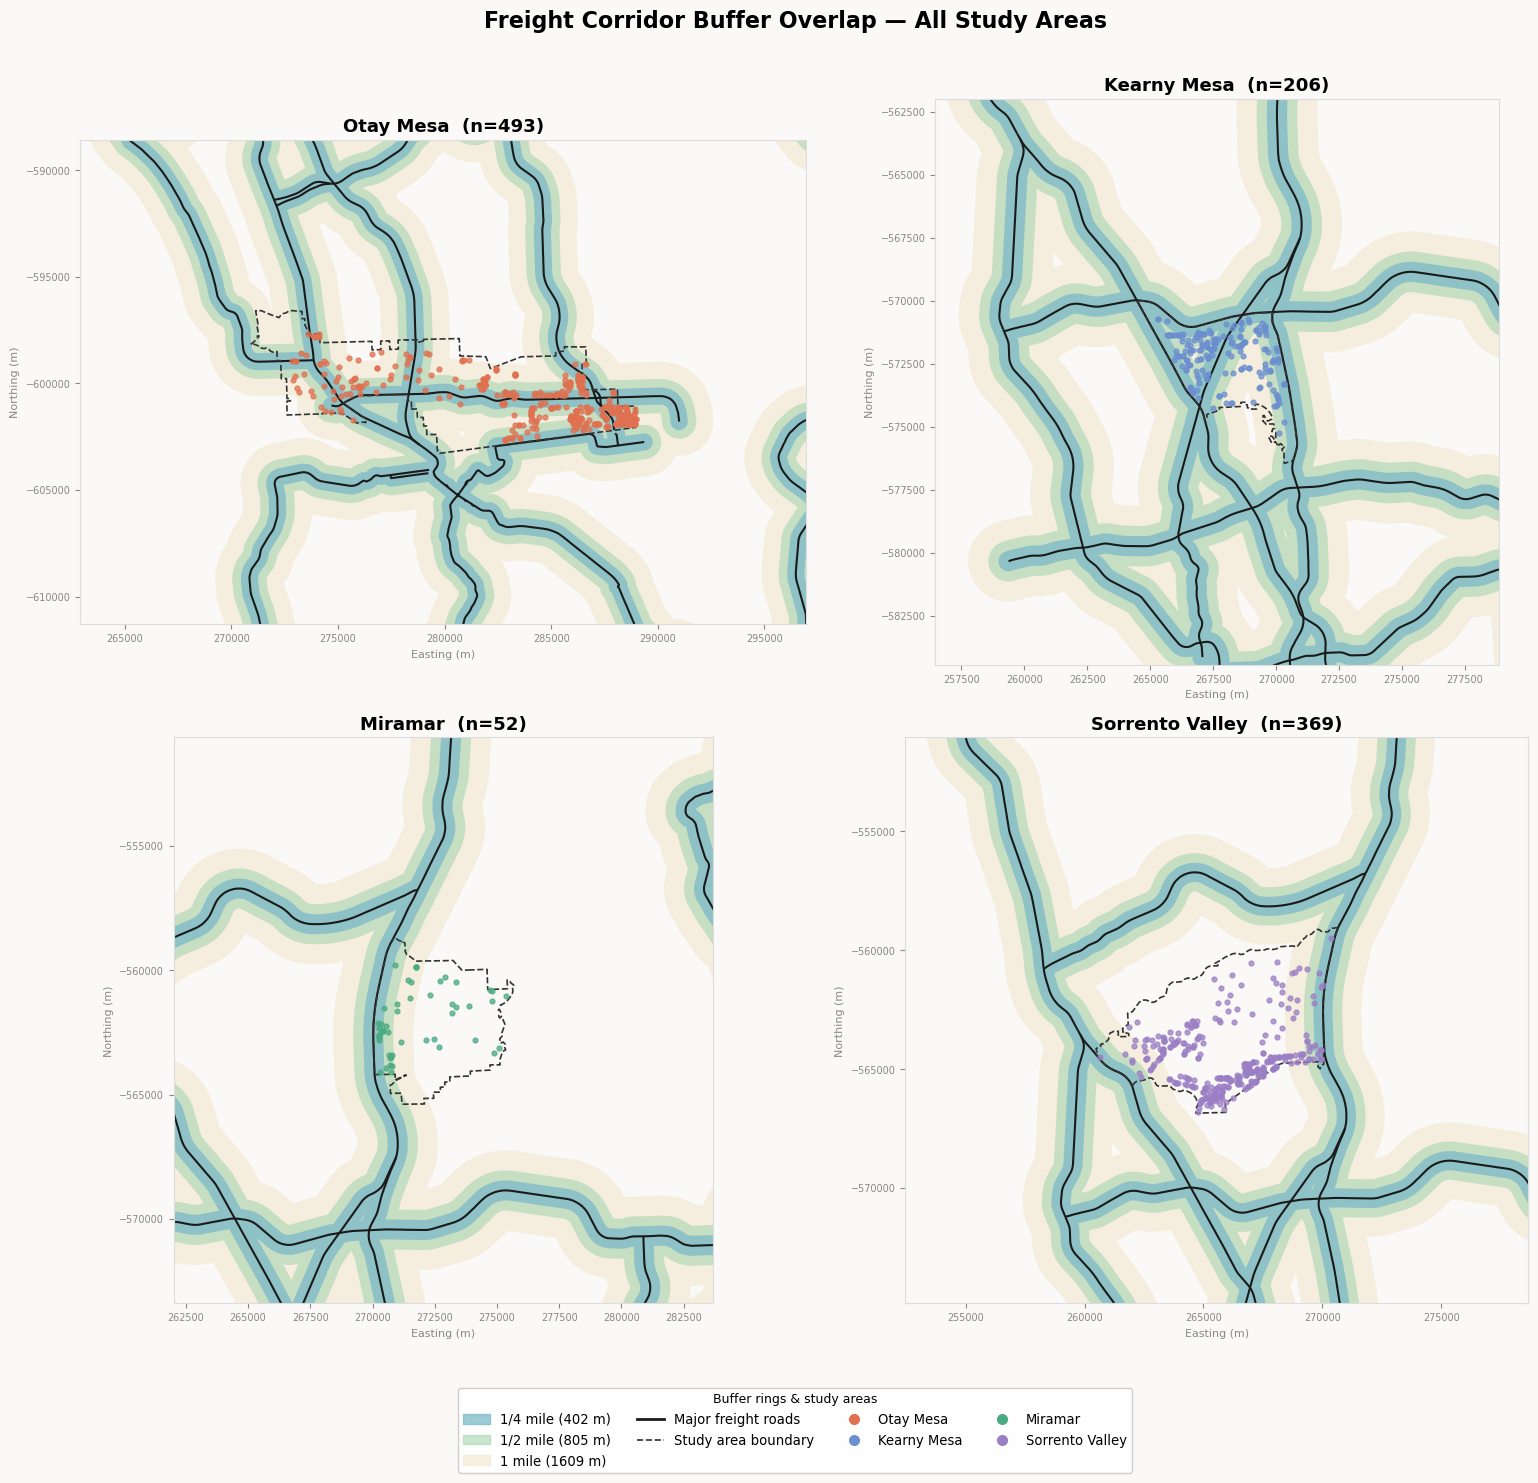

Saved: all_subareas_bullseye_buffer_map.png


In [19]:
# ── Figure C — Bullseye buffer map 2×2 grid ──────────────────────────────────
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

AREA_COLORS_CHART = {
    "Otay Mesa":       "#e07050",
    "Kearny Mesa":     "#6b8fcf",
    "Miramar":         "#4aaa80",
    "Sorrento Valley": "#9b7fc4",
}
BUF_RING_COLORS     = ["#7cb9c8", "#a8d5b0", "#f0e0c0"]
BUF_ALPHAS          = [0.75, 0.60, 0.45]
BUF_DISTANCES_CHART = [402, 805, 1609]

fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor="#faf9f7")
axes = axes.flatten()
fig.suptitle("Freight Corridor Buffer Overlap — All Study Areas",
             fontsize=16, fontweight="bold", y=1.01)

for ax, area in zip(axes, STUDY_AREAS):
    ax.set_facecolor("#faf9f7")
    sub = subarea_gdfs[area]
    n   = len(sub)

    if area in study_area_polys:
        bounds = study_area_polys[area].bounds
    else:
        bounds = sub.total_bounds

    margin = 8000
    xlim = (bounds[0] - margin, bounds[2] + margin)
    ylim = (bounds[1] - margin, bounds[3] + margin)

    # Buffer rings — outermost first
    for dist_m, ring_color, alpha in zip(
            reversed(BUF_DISTANCES_CHART),
            reversed(BUF_RING_COLORS),
            reversed(BUF_ALPHAS)):
        buf_geom = roads_dissolved.buffer(dist_m)
        gpd.GeoDataFrame(geometry=[buf_geom], crs=CRS_PROJ).plot(
            ax=ax, color=ring_color, alpha=alpha, zorder=1)

    # Major roads
    major_roads.plot(ax=ax, color="#1a1a1a", linewidth=1.5, zorder=2)

    # Study area boundary
    if area in study_area_polys:
        gpd.GeoDataFrame(
            geometry=[study_area_polys[area]], crs=CRS_PROJ
        ).boundary.plot(ax=ax, color="#333", linewidth=1.2,
                        linestyle="--", zorder=3)

    # Business points
    sub.plot(ax=ax, color=AREA_COLORS_CHART[area],
             markersize=12, alpha=0.75, zorder=4)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title("{0}  (n={1:,})".format(area, n),
                 fontsize=13, fontweight="bold", pad=6)
    ax.set_xlabel("Easting (m)", fontsize=8, color="#888")
    ax.set_ylabel("Northing (m)", fontsize=8, color="#888")
    ax.tick_params(labelsize=7, colors="#888")
    for spine in ax.spines.values():
        spine.set_edgecolor("#ddd")

legend_elements = [
    mpatches.Patch(color=BUF_RING_COLORS[0], alpha=0.75, label="1/4 mile (402 m)"),
    mpatches.Patch(color=BUF_RING_COLORS[1], alpha=0.60, label="1/2 mile (805 m)"),
    mpatches.Patch(color=BUF_RING_COLORS[2], alpha=0.45, label="1 mile (1609 m)"),
    Line2D([0],[0], color="#1a1a1a", linewidth=2,  label="Major freight roads"),
    Line2D([0],[0], color="#333",    linewidth=1.2,
           linestyle="--",                          label="Study area boundary"),
] + [
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor=AREA_COLORS_CHART[a], markersize=9, label=a)
    for a in STUDY_AREAS
]

fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           fontsize=9.5, frameon=True, framealpha=0.92,
           title="Buffer rings & study areas", title_fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("all_subareas_bullseye_buffer_map.png", dpi=150,
            bbox_inches="tight", facecolor="#faf9f7")
plt.show()
print("Saved: all_subareas_bullseye_buffer_map.png")

Running pairwise statistical tests: Otay Mesa vs each comparison area

── Mann-Whitney U: Otay Mesa vs Kearny Mesa ──
  Otay Mesa  n=493  median=1.094 mi
  Kearny Mesa  n=206  median=20.745 mi
  U=0  p=1.17e-96
  Rank-biserial r=1.000  95% CI [1.000, 1.000]
  Interpretation: statistically significant (large effect)

── Chi-square: Buffer 0.25 mi — Otay Mesa vs Kearny Mesa ──
  Otay Mesa 40.6% | Kearny Mesa 41.3%
  chi2=0.03  p=8.65e-01  Cramér's V=0.006

── Chi-square: Buffer 0.50 mi — Otay Mesa vs Kearny Mesa ──
  Otay Mesa 81.7% | Kearny Mesa 90.3%
  chi2=8.00  p=4.67e-03  Cramér's V=0.107

── Mann-Whitney U: Otay Mesa vs Miramar ──
  Otay Mesa  n=493  median=1.094 mi
  Miramar  n=52  median=25.994 mi
  U=0  p=1.73e-32
  Rank-biserial r=1.000  95% CI [1.000, 1.000]
  Interpretation: statistically significant (large effect)

── Chi-square: Buffer 0.25 mi — Otay Mesa vs Miramar ──
  Otay Mesa 40.6% | Miramar 25.0%
  chi2=4.79  p=2.87e-02  Cramér's V=0.094

── Chi-square: Buffer 0.50 mi

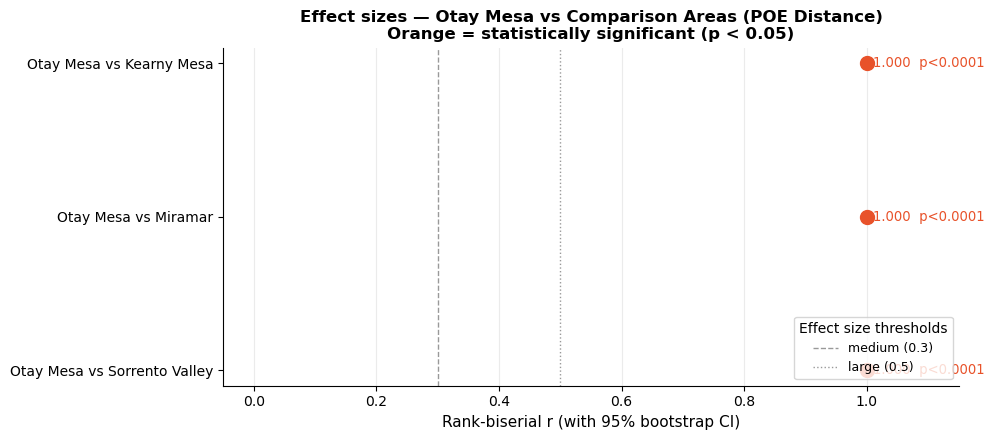

Saved: chart_effect_sizes.png
